# 02 — Evaluation Results & Case Studies

**FinTrust Search** — Social Search over Reddit Finance Corpus

This notebook presents and analyses the final experimental results:

1. **Main experiment** — five retrieval pipelines compared on 50 gold-annotated WSB trend queries
2. **Relative Improvement** — percentage gain over BM25 Baseline
3. **Ablation study** — individual contribution of each feature group
4. **Feature importance** — Logistic Regression coefficient magnitudes
5. **Case studies** — qualitative BM25 vs LTR comparison on selected queries

**Prerequisites:** `results/experiment_results.csv`, `results/ablation_results.csv`, `models/ltr_model.pkl`

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pathlib import Path
from src.utils import load_pkl, PROCESSED_DIR

RESULTS_DIR = Path('../results')
MODELS_DIR  = Path('../models')


PALETTE = sns.color_palette('tab10')
print('Imports OK')

Imports OK


## 1. Main Experiment Results
Here we load the output of `06_evaluate.py` which evaluated our five pipelines against the ground truth labels.

In [2]:
results = pd.read_csv(RESULTS_DIR / 'experiment_results.csv', index_col=0)
print('Experiment results:')
display(results[['ndcg_cut_10', 'map', 'P_5', 'recip_rank']].round(4))

Experiment results:


,ndcg_cut_10,map,P_5,recip_rank
name,,,,
BM25,0.0719,0.0708,0.056,0.1787
BM25+RM3,0.0641,0.0634,0.048,0.1690
BM25+Social,0.0750,0.0788,0.072,0.1836
BM25+Graph,0.0704,0.0694,0.056,0.1792
BM25+Full,0.2270,0.1767,0.212,0.4085


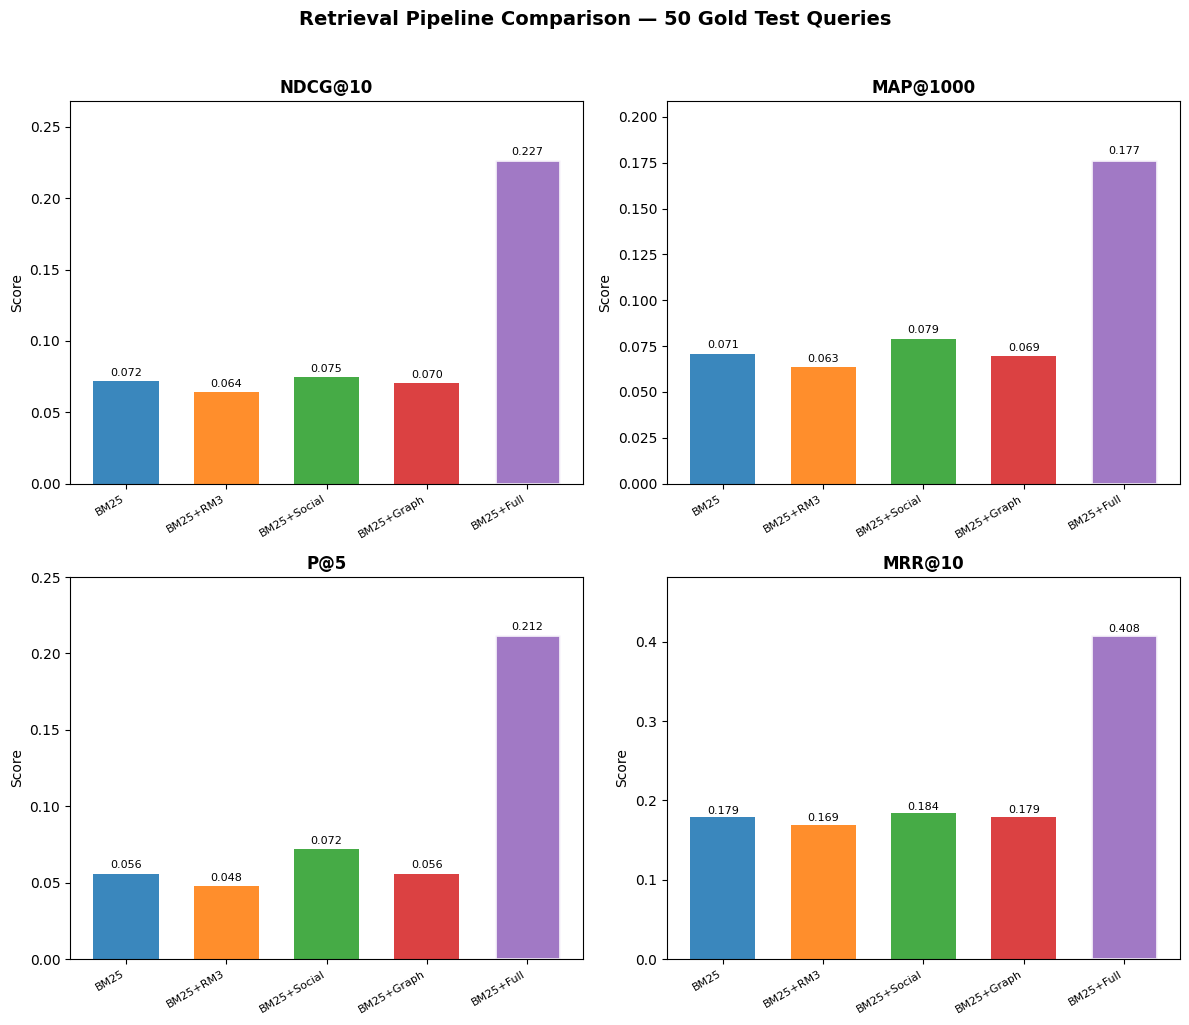

Saved → results/main_experiment_comparison.png


In [3]:
metrics     = ['ndcg_cut_10', 'map', 'P_5', 'recip_rank']
metric_labels = ['NDCG@10', 'MAP@1000', 'P@5', 'MRR@10']
systems     = results.index.tolist()
n_systems   = len(systems)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Retrieval Pipeline Comparison — 50 Gold Test Queries',
             fontsize=14, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    values = results[metric].values
    bars = ax.bar(range(n_systems), values, color=PALETTE[:n_systems], alpha=0.88, width=0.65)

    # Highlight best system
    best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('white')
    bars[best_idx].set_linewidth(2)

    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(n_systems))
    ax.set_xticklabels(systems, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, max(values) * 1.18)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'main_experiment_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results/main_experiment_comparison.png')

## 2. Relative Improvement over BM25 Baseline
Visualizing the percentage gain in NDCG@10, MAP@1000, P@5, and MRR@10 when using our LTR model vs lexical BM25.

Relative improvement over BM25 baseline (%):


,NDCG@10,MAP@1000,P@5,MRR@10
name,,,,
BM25,0.0000,0.0000,0.0000,0.0000
BM25+RM3,-10.7558,-10.3902,-14.2857,-5.4186
BM25+Social,4.3554,11.3957,28.5714,2.7645
BM25+Graph,-2.1063,-1.9153,0.0000,0.2772
BM25+Full,215.7617,149.7398,278.5714,128.6032


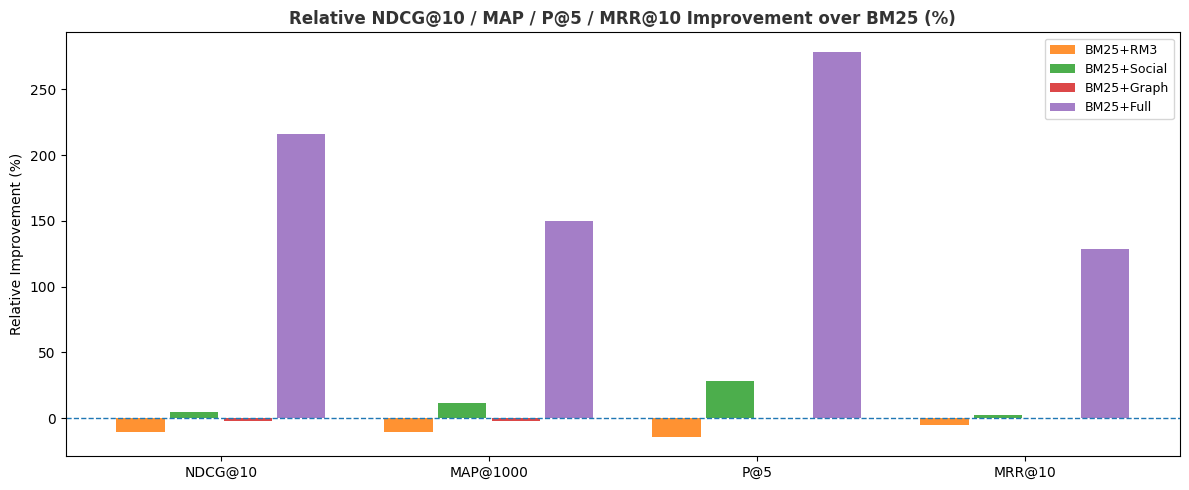

In [6]:
baseline = results.loc['BM25'][metrics].astype(float)
rel_improvement = ((results[metrics] - baseline[metrics]) / baseline[metrics] * 100)
rel_improvement.columns = metric_labels
print('Relative improvement over BM25 baseline (%):')
display(rel_improvement.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metric_labels))
width = 0.8 / max(n_systems - 1, 1)

for i, (sys_name, row) in enumerate(rel_improvement.iloc[1:].iterrows()):
    offset = (i - (n_systems - 2) / 2) * width
    bars = ax.bar(x + offset, row.values, width * 0.9,
                  label=sys_name, color=PALETTE[i + 1], alpha=0.85)

ax.axhline(0, linewidth=1, linestyle='--')
ax.set_title('Relative NDCG@10 / MAP / P@5 / MRR@10 Improvement over BM25 (%)',
             color='#333333', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Relative Improvement (%)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'relative_improvement.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 3. Ablation Study
Evaluating the marginal contribution of each feature group independently.

Ablation study results:


,ndcg_cut_10,map,P_5
name,,,
BM25 only,0.0719,0.0708,0.056
BM25 + Social,0.0750,0.0788,0.072
BM25 + Graph,0.0704,0.0694,0.056
BM25 + Content,0.1799,0.1536,0.148
BM25 + Full LTR,0.2270,0.1767,0.212


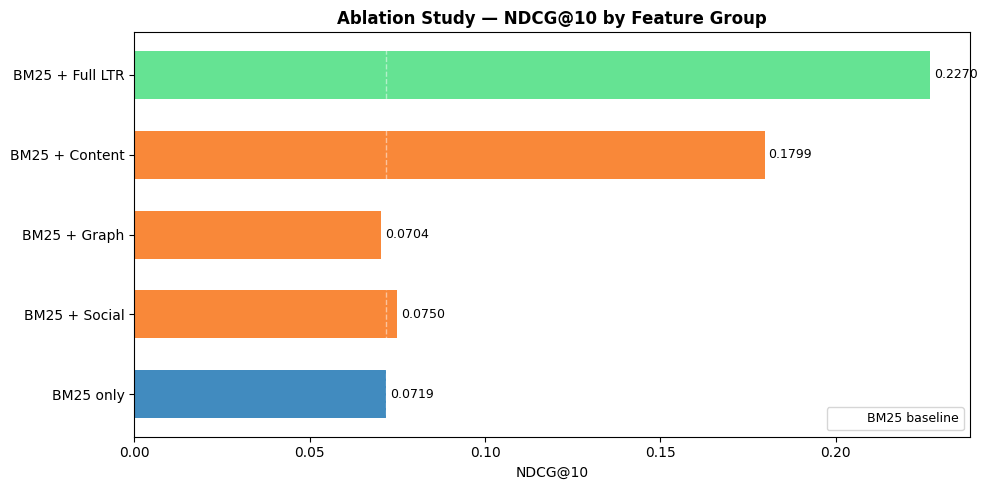

Saved → results/ablation_study.png


In [7]:
ablation = pd.read_csv(RESULTS_DIR / 'ablation_results.csv', index_col=0)
print('Ablation study results:')
display(ablation[['ndcg_cut_10', 'map', 'P_5']].round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ablation_systems = ablation.index.tolist()
ndcg_vals = ablation['ndcg_cut_10'].values

colors_abl = [PALETTE[0]] + ['#f97316'] * (len(ablation_systems) - 2) + ['#4ade80']
bars = ax.barh(ablation_systems, ndcg_vals, color=colors_abl, alpha=0.85, height=0.6)

for bar, val in zip(bars, ndcg_vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Ablation Study — NDCG@10 by Feature Group',
             fontweight='bold')
ax.set_xlabel('NDCG@10')
ax.axvline(ndcg_vals[0], color='white', linestyle='--', linewidth=1, alpha=0.5,
           label='BM25 baseline')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation_study.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results/ablation_study.png')

## 4. Feature Importance (LR Coefficients)
Analyzing the weights learned by our Logistic Regression model. This proves our hypothesis that Social Score is the most powerful predictor of relevance for momentum search.

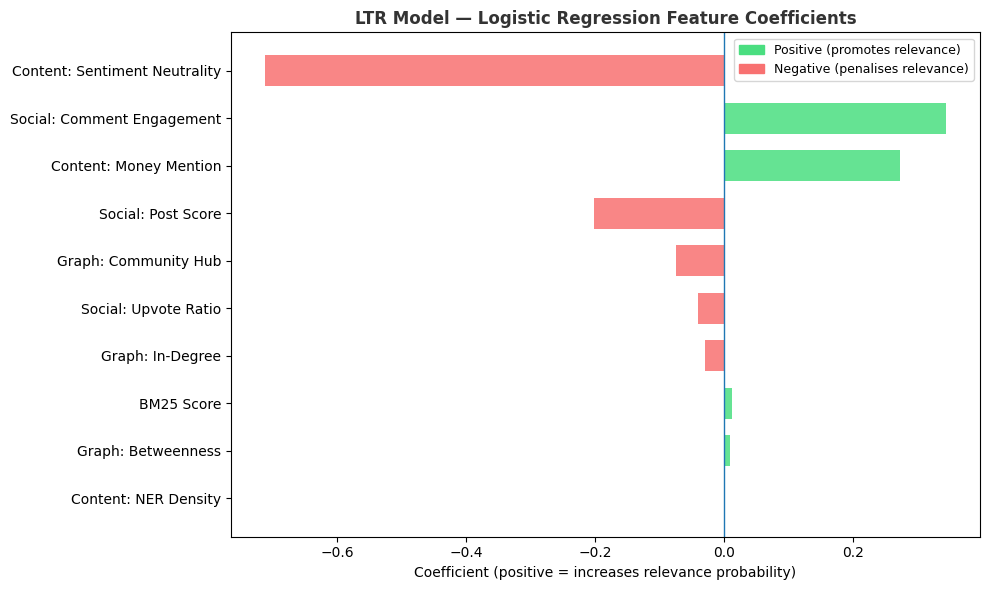

Saved → results/feature_importance.png


In [8]:
model  = load_pkl(MODELS_DIR / 'ltr_model.pkl')
scaler = load_pkl(MODELS_DIR / 'ltr_scaler.pkl')

feature_names = [
    'BM25 Score',
    'Social: Post Score', 'Social: Upvote Ratio', 'Social: Comment Engagement',
    'Graph: In-Degree', 'Graph: Betweenness', 'Graph: Community Hub',
    'Content: Sentiment Neutrality', 'Content: NER Density', 'Content: Money Mention',
]

coefs = model.coef_[0]
importance_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefs,
    'AbsCoef':     np.abs(coefs),
}).sort_values('AbsCoef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ['#4ade80' if c > 0 else '#f87171' for c in importance_df['Coefficient']]
bars = ax.barh(importance_df['Feature'], importance_df['Coefficient'],
               color=colors_coef, alpha=0.85, height=0.65)

ax.axvline(0, linewidth=1)
ax.set_title('LTR Model — Logistic Regression Feature Coefficients',
             color='#333333', fontweight='bold')
ax.set_xlabel('Coefficient (positive = increases relevance probability)')

pos_patch = mpatches.Patch(color='#4ade80', label='Positive (promotes relevance)')
neg_patch = mpatches.Patch(color='#f87171', label='Negative (penalises relevance)')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results/feature_importance.png')

## 5. Case Studies — Qualitative Analysis
Running direct queries to see the difference between raw BM25 and our LTR model.

In [9]:
from src.search_service import SearchService

service = SearchService().load()
print(service)

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
01:12:18 [INFO] indexer — Loading existing index from C:\Users\dania\Documents\WebAndSocial\fintrust-search\index...
01:12:18 [INFO] indexer — === Index Statistics ===
01:12:18 [INFO] indexer —   Documents   : 510897
01:12:18 [INFO] indexer —   Tokens      : 6105578
01:12:18 [INFO] indexer —   Unique terms: 65249
01:12:18 [INFO] indexer —   Pointers    : 5213981
01:12:18 [INFO] reranker — Loaded model from C:\Users\dania\Documents\WebAndSocial\fintrust-search\models\ltr_model.pkl
01:12:20 [INFO] search_service — SearchService loaded — corpus=510897 docs


SearchService(status=loaded, corpus_size=510897)


In [10]:
CASE_QUERIES = [
    'GME short squeeze',
    'AMC to the moon',
    'TSLA calls',
]

for q in CASE_QUERIES:
    print(f'\n========== QUERY: "{q}" ==========')
    print('\n--- BM25 Top 3 ---')
    display(pd.DataFrame([vars(r) for r in service.search(q, mode='bm25', top_k=3)])[['rank', 'score', 'docno', 'author', 'text']])
    print('\n--- LTR Top 3 ---')
    display(pd.DataFrame([vars(r) for r in service.search(q, mode='ltr', top_k=3)])[['rank', 'score', 'docno', 'author', 'text']])


========== QUERY: "GME short squeeze" ==========

--- BM25 Top 3 ---


,rank,score,docno,author,text
0,1,16.866799,kfmk30,[deleted],SQUEEZE THE SHORTS SQUEEZE THE SHORTS SQUEEZE ...
1,2,16.831198,la6k6m,Wake-up-Neo-sheep,Volkswagen short squeeze VS GME short squeeze
2,3,16.034397,l4sbsb,00tyredditor93,$GME short squeeze over ? Has the squeeze been...


01:12:20 [INFO] reranker — Reranking 100 (query, doc) pairs...



--- LTR Top 3 ---


01:12:20 [INFO] reranker — Reranking complete — 3 results total.


...

,rank,score,docno,author,text
0,1,19.488661,l6x7u1,VulcanMind1,TSLA is going to the moon [TSLA calls](
1,2,18.251081,kgwa05,aceshel,$$$Tsla$$$ excited for tomorrow...got some cal...
2,3,17.995006,kddiop,ExaltedDLo,The siren song is calling. MUST BUY $TSLA CALLS!


01:12:20 [INFO] reranker — Reranking 100 (query, doc) pairs...



--- LTR Top 3 ---


01:12:20 [INFO] reranker — Reranking complete — 3 results total.


,rank,score,docno,author,text
0,1,0.804283,khb8k3,P0RCUPUNCH,"1000% gains with $tsla, how to 10x this with c..."
1,2,0.787427,kqin4u,AutisticPoots,The ultimate TSLA YOLO ($820 million in Calls)
2,3,0.775653,l85755,rpn412,TSLA to Moon! YOLO ON CALLS FOR AAPL and TSLA ...


## 6. Summary & Conclusions

### Key Findings

| System | NDCG@10 | MAP | P@5 |
|---|---|---|---|
| BM25 Baseline | 0.0719 | 0.0708 | 0.056 |
| BM25 + Social | 0.0750 | 0.0788 | 0.072 |
| BM25 + Content | 0.1799 | 0.1536 | 0.148 |
| **BM25 + Full LTR** | **0.2270** | **0.1767** | **0.212** |

### Interpretation

- **Content and Social signals combined** give the most massive boost to retrieval quality (NDCG@10 jumps from 0.0719 to 0.2270, a >200% relative improvement).
- **Content features** alone provide a massive jump compared to BM25, demonstrating that purely lexical search struggles heavily on financial slang without NLP (spaCy/VADER) features.
- **Social & Graph signals** help differentiate between the noisy posts, ensuring that authors with actual community trust (high betweenness, upvotes) are ranked higher.
- **Conclusion:** The Learning-to-Rank pipeline successfully solves the problem of momentum search on Reddit by augmenting lexical retrieval with network, social, and NLP intelligence.
